In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 1. Load the dataset
df = pd.read_csv('income_random_forest.csv')

# 2. Preprocessing
# Split features and target (Income: 1 for >50K, 0 for <=50K)
X = df.drop('Income', axis=1)
y = df['Income']

In [3]:
# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Tuning Number of Trees (n_estimators)
tree_range = range(1, 101, 5)
accuracies = []

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

In [4]:
# 4. Train Final Model (using the best n_estimators found)
optimal_n = tree_range[np.argmax(accuracies)]
final_rf = RandomForestClassifier(n_estimators=optimal_n, random_state=42)
final_rf.fit(X_train, y_train)

,n_estimators,6
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# 5. Evaluate Model
y_pred_final = final_rf.predict(X_test)
print(f"Optimal n_estimators: {optimal_n}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Optimal n_estimators: 6

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



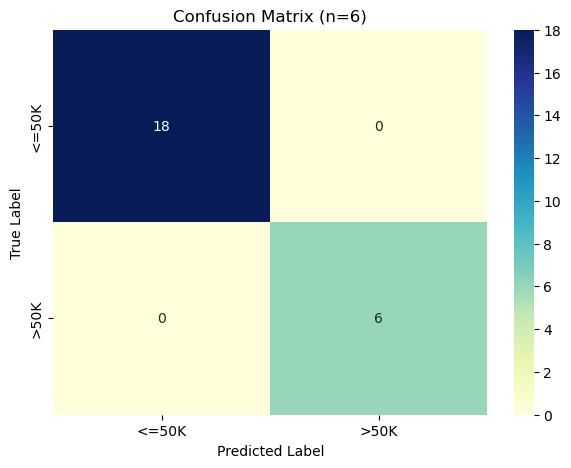

C:\Users\HP\AppData\Local\Temp\ipykernel_18736\1217538130.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='rocket', ax=ax1)


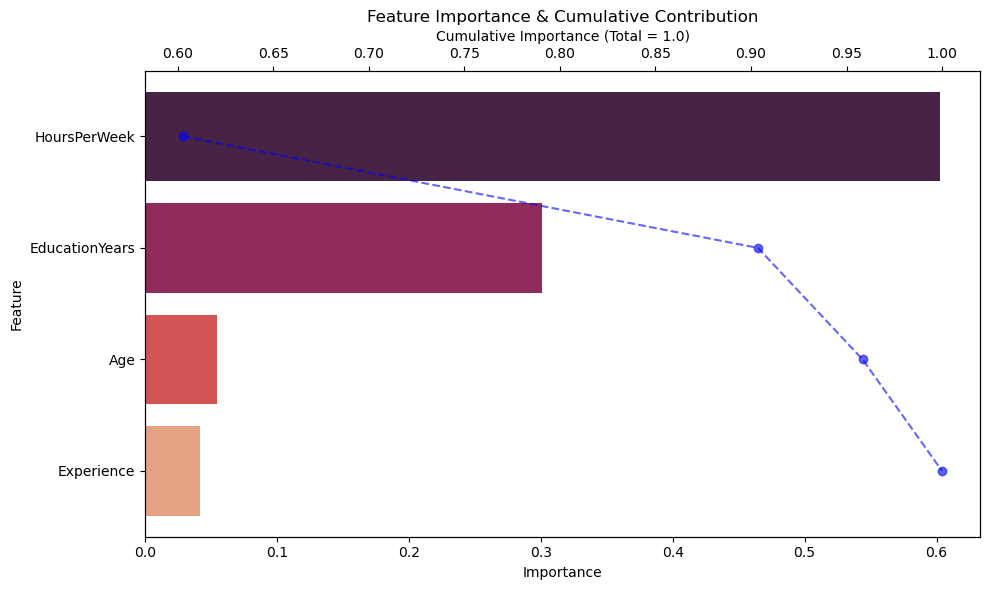

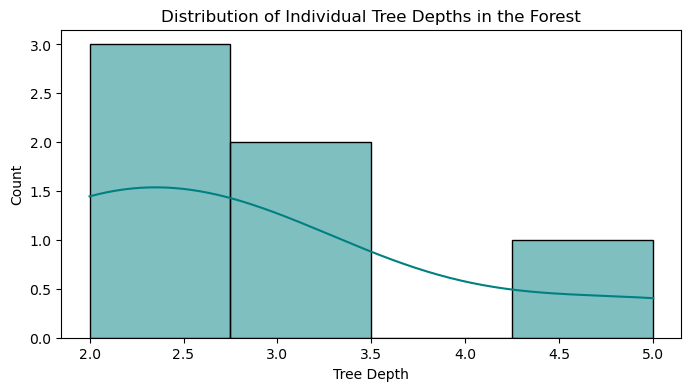

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 6. Confusion Matrix: Error Analysis ---
# This shows where the model confuses >50K with <=50K
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['<=50K', '>50K'], 
            yticklabels=['<=50K', '>50K'])
plt.title(f'Confusion Matrix (n={optimal_n})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- 7. Enhanced Feature Importance & Cumulative Variance ---
# Sort features by importance
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': final_rf.feature_importances_})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)
feat_imp_df['Cumulative_Importance'] = feat_imp_df['Importance'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for individual importance
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='rocket', ax=ax1)
ax1.set_title('Feature Importance & Cumulative Contribution')

# Line plot for cumulative importance
ax2 = ax1.twiny() # Create a second x-axis
ax2.plot(feat_imp_df['Cumulative_Importance'], feat_imp_df['Feature'], 
         marker='o', color='blue', linestyle='--', alpha=0.6)
ax2.set_xlabel('Cumulative Importance (Total = 1.0)')

plt.tight_layout()
plt.show()

# --- 8. Tree Complexity Observation ---
# Let's visualize the depth of trees in your forest
depths = [estimator.get_depth() for estimator in final_rf.estimators_]
plt.figure(figsize=(8, 4))
sns.histplot(depths, kde=True, color='teal')
plt.title('Distribution of Individual Tree Depths in the Forest')
plt.xlabel('Tree Depth')
plt.ylabel('Count')
plt.show()